In [1]:
#synthetic Geopotential dataset at 500 hPa (Z_500)
#turn 2D atmospheric field into a sequence of tokens, and embed coordinates to give the model geographic awareness.

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(40)
np.random.seed(40)

In [2]:
#predict Z_500, to cpature synpotic-scale patterns in high and low pressure
#generate synthetic Z_500

def generate_syn_z500(n_samples , H , W, seed) -> np.ndarray:
    """Generate synthetic Z500-like fields.  
    H and W are grid dimensions
    seed for random seed generation
    Returns array of shape (n_samples, H, W)."""
    rng = np.random.default_rng(seed)
    lats = np.linspace(-np.pi / 2, np.pi / 2, H)
    zonal_mean = (55000 - 3000 * np.abs(np.sin(lats)))[:, None]
    #simplified zonal mean that decreases symmetrically from the equator to the poles based on latitude.

    fields = np.zeros((n_samples, H, W), dtype=np.float32)
    perturbation = rng.standard_normal((H, W)).astype(np.float32) * 500
    #draw samples from satndard normal distribution of rng

    for i in range(n_samples):
        perturbation = 0.97 * perturbation + (rng.standard_normal((H, W)) * 150).astype(np.float32)
        for _ in range(3):
            p = np.pad(perturbation, ((2, 2), (2, 2)), mode='wrap')
            blurred = sum(
                p[r:r + H, c:c + W]
                for r in range(5) for c in range(5)
            ) / 25
            perturbation = blurred.astype(np.float32)
        fields[i] = zonal_mean + perturbation

    return fields

In [3]:
#coarse-grid : 32x64 ~5.6deg resolution.

z500_syn_raw = generate_syn_z500(n_samples=500, H= 32, W=64, seed= 40)
print(f"Dataset shape : {z500_syn_raw.shape}")
print(f"Value range   : {z500_syn_raw.min():.0f} – {z500_syn_raw.max():.0f} m²/s²")
print(f"Global mean   : {z500_syn_raw.mean():.0f} m²/s²")
print(f"Global std    : {z500_syn_raw.std():.0f} m²/s²")

Dataset shape : (500, 32, 64)
Value range   : 51886 – 54962 m²/s²
Global mean   : 53058 m²/s²
Global std    : 928 m²/s²


In [4]:
#normalise the data (data_point - mean / std)

z500_syn_norm = (z500_syn_raw - z500_syn_raw.mean()) / z500_syn_raw.std()

print(f"Normalised z500 mean : {z500_syn_norm.mean() :.4f}")
print(f"Normalised z500 std  : {z500_syn_norm.std() :.4f}")

Normalised z500 mean : 0.0000
Normalised z500 std  : 1.0000


Text(0.5, 0.98, 'Synthetic Z_500')

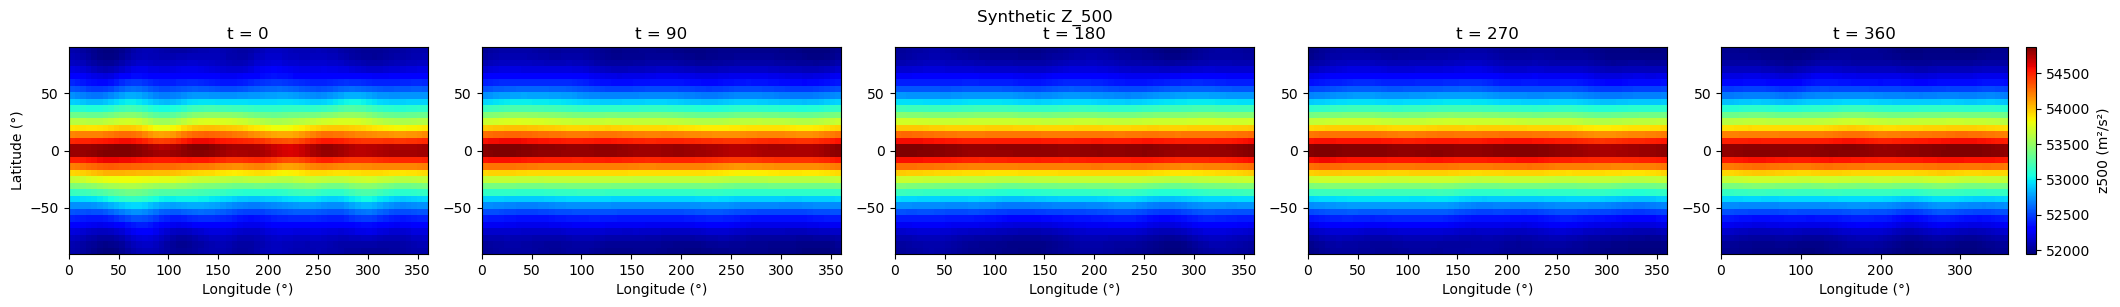

In [5]:
#visualise raw z500 fields to confirm the data looks physically reasonable

lats_deg = np.linspace(-90, 90, 32) #H = 32
lons_deg = np.linspace(0, 360, 64, endpoint=False) #W = 64, and for lon 0 and 360 are the same line
fig, axes = plt.subplots(1, 5, figsize = (21,3))

for i, ax in enumerate(axes):
    t = i * 90
    im = ax.imshow(z500_syn_raw[t], extent=[0, 360, -90, 90], cmap='jet', aspect='auto')
    ax.set_title(f"t = {t}")
    ax.set_xlabel("Longitude (°)")
    if i == 0:
        ax.set_ylabel("Latitude (°)")

plt.tight_layout()
plt.colorbar(im, label="z500 (m²/s²)")
plt.suptitle("Synthetic Z_500", va = 'center')

In [6]:
#design a model to learn the mapping from the current state to the next state i.e.,
#using  normalised z500 field at time step t, predict the field at time step t+1.

#and for training the model split the data (80% for training , 20% for testing)

#prepare a torch dataset
class Z500Dataset(Dataset):
    def __init__(self, z500: np.ndarray, lead: int = 1):
        self.data = torch.from_numpy(z500).unsqueeze(1)  #(T, 1, H, W) shape
        self.lead = lead

    def __len__(self):
        return len(self.data) - self.lead

    def __getitem__(self, idx):
        return self.data[idx], self.data[idx + self.lead]

n_train = int(0.8 * len(z500_syn_norm))
train_ds = Z500Dataset(z500_syn_norm[:n_train])
val_ds   = Z500Dataset(z500_syn_norm[n_train:])

train_loader = DataLoader(train_ds, batch_size= 10, shuffle=True) #data reshuffled at every epoch
val_loader   = DataLoader(val_ds,   batch_size= 10) #10 samples per batch to load

In [7]:
print(f"no: of training samples   : {len(train_ds)}")
print(f"no:of validation samples : {len(val_ds)}")
input_batch, output_batch = next(iter(train_loader))
print(f"Batch shapes for i/o    : input {tuple(input_batch.shape)},  target {tuple(output_batch.shape)}")

no: of training samples   : 399
no:of validation samples : 99
Batch shapes for i/o    : input (10, 1, 32, 64),  target (10, 1, 32, 64)


In [8]:
#patchification: transformer processes a sequence of vectors/tokens not spatial grid, so-
#simple division of the 2D (spatial) grid into non-overlapping rectangular patches is done. 
#which (patches) are then flattened into vectors/tokens

In [9]:
#for a field (H,W) = (32, 64) a patch size of 4 is used.
#so each patch has 4x4 = 16 values, and each row will have 16 patches
#then final patches are 128 (2[32/16] * 4[64/16] = 8 , 8 * 16 = 128)

def patchification(x: torch.Tensor, P) -> torch.Tensor:
    """
    x: (B, C, H, W)
    P is patch size
    Returns: (B, N, C*P*P)  where N = (H//P) * (W//P)
    """
    B, C, H, W = x.shape
    nh, nw = H // P, W // P
    x = x.reshape(B, C, nh, P, nw, P)
    x = x.permute(0, 2, 4, 1, 3, 5).contiguous()  #(B, nh, nw, C, P, P)
    x = x.reshape(B, nh * nw, C * P * P)
    return x


def unpatchification(patches: torch.Tensor, H, W, P) -> torch.Tensor:
    """
    patches: (B, N, P*P)  — single-channel output patches
    P is patch size, H and W are lat and lon defined for the grid
    Returns: (B, 1, H, W)
    """
    B, N, _ = patches.shape
    nh, nw = H // P, W // P
    x = patches.reshape(B, nh, nw, P, P)
    x = x.permute(0, 1, 3, 2, 4).contiguous()  #(B, nh, P, nw, P)
    x = x.reshape(B, 1, H, W)
    return x

In [10]:
PATCH_SIZE = 4

patched = patchification(input_batch, P=PATCH_SIZE)
print(f"patching  : {tuple(patched.shape)}")

recovered = unpatchification(patched, H= 32, W= 64, P=PATCH_SIZE)
print(f"unpatching  : {tuple(recovered.shape)}")

patching  : (10, 128, 16)
unpatching  : (10, 1, 32, 64)


In [11]:
#since z500 is high around the equator, lower towards the poles, there is positional dependence.
#so, add two extra channels to the input field before patchification

lats_norm = torch.linspace(-1, 1, 32) #H
lons_norm = torch.linspace(-1, 1, 64) #W

lat_grid, lon_grid = torch.meshgrid(lats_norm, lons_norm, indexing='ij')

latlon = torch.stack([lat_grid, lon_grid], dim=0)  #(2, H, W)

print(f"latlon shape : {tuple(latlon.shape)}")
print(f"lat  range   : {lat_grid.min():.2f} to {lat_grid.max():.2f}")
print(f"lon  range   : {lon_grid.min():.2f} to {lon_grid.max():.2f}")

latlon shape : (2, 32, 64)
lat  range   : -1.00 to 1.00
lon  range   : -1.00 to 1.00


In [12]:
#patch transformer: 1. self-attention computes three projections per token: a query, a key, and a value
#and stack such that, each grid cell carries three numbers: its geopotential value, its latitude, and its longitude
#(B samples, 3, H, W) and patch (B samples, 128 patches , 3 * 4x4 [patch_size x patch_size])

In [13]:
class PatchTransformer(nn.Module):
    def __init__(
        self,
        spatial_shape: tuple = (32, 64), #(H,W)
        patch_size: int = 4, #P
        d_model: int = 64,
        nhead: int = 4, 
        num_layers: int = 2,
    ):
        super().__init__()
        self.H, self.W = spatial_shape
        self.P = patch_size
        P = patch_size
        N = (self.H // P) * (self.W // P)

        #3 channels (z500, lat, lon), each P×P pixels per patch
        self.patch_embedding = nn.Linear(3 * P * P, d_model)

        self.pos_embedding = nn.Parameter(torch.zeros(1, N, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            batch_first=True,
            dropout=0.0,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        #P*P pixel values per patch (single output channel)
        self.output_head = nn.Linear(d_model, P * P)

    def forward(self, x: torch.Tensor, latlon: torch.Tensor) -> torch.Tensor:
        """
        x      : (B, 1, H, W)  normalised z500
        latlon : (2, H, W)     normalised lat/lon grids
        Returns: (B, 1, H, W)
        """
        B = x.shape[0]
        ll = latlon.unsqueeze(0).expand(B, -1, -1, -1)

        x_full = torch.cat([x, ll], dim=1)          #(B, 3, H, W)
        tokens = patchification(x_full, self.P)             #(B, N, 3*P²)
        tokens = self.patch_embedding(tokens) + self.pos_embedding
        tokens = self.transformer(tokens)
        out_patches = self.output_head(tokens)        #(B, N, P²)
        return unpatchification(out_patches, self.H, self.W, self.P)

In [14]:
model = PatchTransformer(spatial_shape=(32, 64), patch_size= PATCH_SIZE, d_model=64, 
                         nhead=4, num_layers= 2)
with torch.no_grad():
    out = model(input_batch, latlon)
print(f"Input  shape : {tuple(input_batch.shape)}")
print(f"Output shape : {tuple(out.shape)}")

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Input  shape : (10, 1, 32, 64)
Output shape : (10, 1, 32, 64)
Trainable parameters: 112,336


In [15]:
#train and evaluate
def train_one_epoch(model, loader, optimiser, criterion, latlon):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        optimiser.zero_grad()
        pred = model(x, latlon)
        loss = criterion(pred, y)
        loss.backward()
        optimiser.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, latlon):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            pred = model(x, latlon)
            loss = criterion(pred, y)
            total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

In [16]:
NUM_EPOCHS = 10
LR = 1e-3

model = PatchTransformer(spatial_shape=(32, 64), patch_size=PATCH_SIZE, 
                            d_model=64, nhead=4, num_layers=2)
optimiser = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses = []
val_losses   = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimiser, criterion, latlon)
    train_losses.append(train_loss)

    val_loss = evaluate(model, val_loader, criterion, latlon)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}")

Epoch  1/10  train=0.1516  val=0.0101
Epoch  2/10  train=0.0029  val=0.0009
Epoch  3/10  train=0.0007  val=0.0007
Epoch  4/10  train=0.0006  val=0.0006
Epoch  5/10  train=0.0006  val=0.0006
Epoch  6/10  train=0.0006  val=0.0006
Epoch  7/10  train=0.0005  val=0.0006
Epoch  8/10  train=0.0006  val=0.0006
Epoch  9/10  train=0.0005  val=0.0006
Epoch 10/10  train=0.0005  val=0.0005


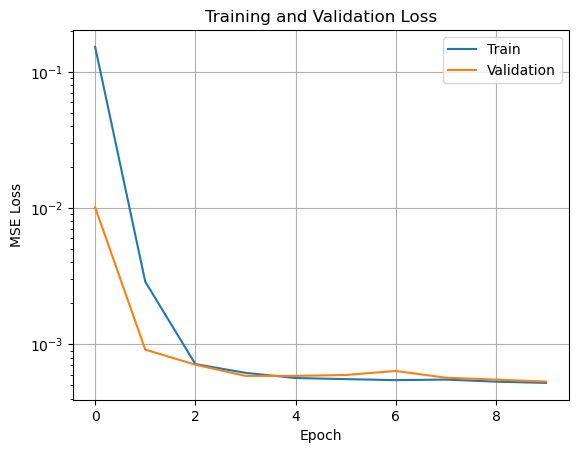

In [17]:
plt.semilogy(train_losses, label="Train")
plt.plot(val_losses,   label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

Text(0.5, 0.98, 'Transformer Forecast vs. Ground Truth')

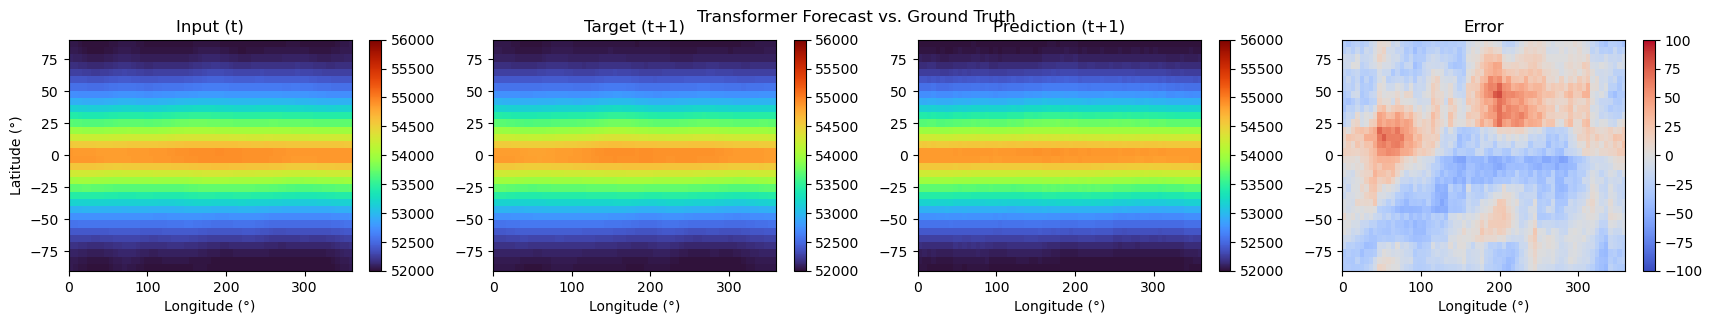

In [18]:
#compare the model's predictions against the ground truth target field

model.eval()
x_vis, y_vis = val_ds[0]
x_vis = x_vis.unsqueeze(0)
y_vis = y_vis.unsqueeze(0)

with torch.no_grad():
    pred_vis = model(x_vis, latlon)

def denorm(t):
    return t.squeeze().numpy() * z500_syn_raw.std() + z500_syn_raw.mean()

x_plot    = denorm(x_vis)
y_plot    = denorm(y_vis)
pred_plot = denorm(pred_vis)
error     = pred_plot - y_plot

fig, axes = plt.subplots(1, 4, figsize=(21, 3))
titles = ["Input (t)", "Target (t+1)", "Prediction (t+1)", "Error"]
data   = [x_plot, y_plot, pred_plot, error]
cmaps  = ["turbo", "turbo", "turbo", "coolwarm"]
vlims  = [(52000, 56000), (52000, 56000), (52000, 56000), (-100, 100)]

for ax, title, field, cmap, (vmin, vmax) in zip(axes, titles, data, cmaps, vlims):
    im = ax.imshow(field, origin='lower', aspect='auto',
                   extent=[0, 360, -90, 90], cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Longitude (°)")
    plt.colorbar(im, ax=ax)

axes[0].set_ylabel("Latitude (°)")
plt.suptitle("Transformer Forecast vs. Ground Truth")

In [19]:
#evalute the model performance more meaningfully by comparing it to a persistence baseline
#assumption; where target is equal to input

all_preds, all_targets, all_inputs = [], [], []
model.eval()
with torch.no_grad():
    for x, y in val_loader:
        pred = model(x, latlon)
        all_preds.append(pred)
        all_targets.append(y)
        all_inputs.append(x)

preds   = torch.cat(all_preds)
targets = torch.cat(all_targets)
inputs  = torch.cat(all_inputs)

rmse_model       = ((preds - targets) ** 2).mean().sqrt().item()
rmse_persistence = ((inputs - targets) ** 2).mean().sqrt().item()

print(f"RMSE – Transformer  : {rmse_model:.4f} (normalised)")
print(f"RMSE – Persistence  : {rmse_persistence:.4f} (normalised)")
print(f"Improvement over persistence: {(1 - rmse_model / rmse_persistence) * 100:.1f}%")
print()
print(f"RMSE – Transformer  : {rmse_model * z500_syn_raw.std() :.1f} m²/s² ")
print(f"RMSE – Persistence  : {rmse_persistence *  z500_syn_raw.std() :.1f} m²/s² ")

RMSE – Transformer  : 0.0231 (normalised)
RMSE – Persistence  : 0.0199 (normalised)
Improvement over persistence: -15.9%

RMSE – Transformer  : 21.4 m²/s² 
RMSE – Persistence  : 18.5 m²/s² 
